# Churn Intelligence Platform EDA

This notebook focuses on exploratory analysis of the final processed churn dataset. It uses the cleaned dataset generated by the production pipeline and is meant to support project storytelling, not data preparation.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.generate_eda import EDA_OUTPUT_DIR, load_dataset

sns.set_theme(style='whitegrid')

In [2]:
df = load_dataset()
print(df.shape)
df.head()

(7043, 30)


,customerID,gender,SeniorCitizen,Dependents,tenure,PhoneService,DeviceProtection,TechSupport,Contract,PaperlessBilling,...,high_value_customer,has_complaint,has_internet,fiber_user,complaint_text_length,complaint_negative_score,complaint_negative_flag,billing_issue_flag,technical_issue_flag,service_issue_flag
0,1024-GUALD,Female,0,0,1,0,0,0,Month-to-month,1,...,0,1,1,0,118,0,0,0,0,0
1,0484-JPBRU,Male,0,0,41,1,0,0,Month-to-month,1,...,0,1,0,0,94,0,0,0,0,0
2,3620-EHIMZ,Female,0,1,52,1,0,0,Two year,0,...,0,1,0,0,772,0,0,0,1,1
3,6910-HADCM,Female,0,0,1,1,1,0,Month-to-month,0,...,0,1,1,1,26,0,0,0,0,0
4,8587-XYZSF,Male,0,0,67,1,0,1,Two year,0,...,0,1,1,0,1132,2,1,1,0,1


In [3]:
df[['Churn', 'tenure', 'MonthlyCharges', 'TotalCharges', 'num_complaints', 'support_calls']].describe()

,Churn,tenure,MonthlyCharges,TotalCharges,num_complaints,support_calls
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265370,32.371149,64.761692,2279.734304,1.368877,1.862417
std,0.441561,24.559481,30.090047,2266.794470,1.382410,1.463641
min,0.000000,0.000000,18.250000,0.000000,0.000000,0.000000
25%,0.000000,9.000000,35.500000,398.550000,0.000000,1.000000
50%,0.000000,29.000000,70.350000,1394.550000,1.000000,2.000000
75%,1.000000,55.000000,89.850000,3786.600000,2.000000,2.000000
max,1.000000,72.000000,118.750000,8684.800000,5.000000,6.000000


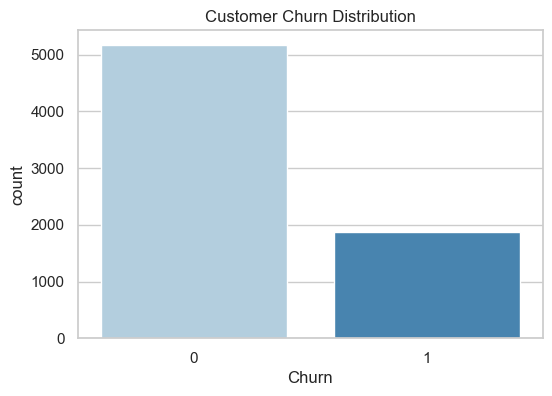

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', palette='Blues')
plt.title('Customer Churn Distribution')
plt.show()

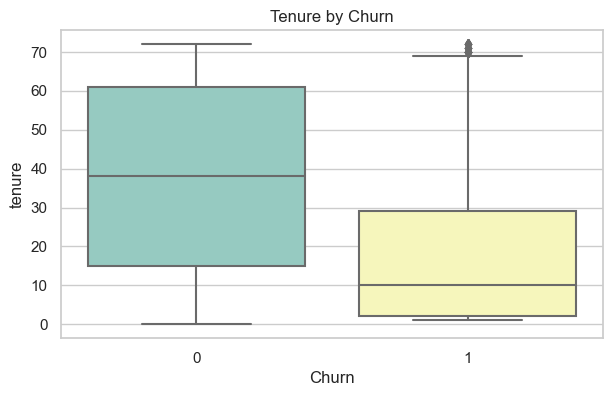

In [5]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='Churn', y='tenure', palette='Set3')
plt.title('Tenure by Churn')
plt.show()

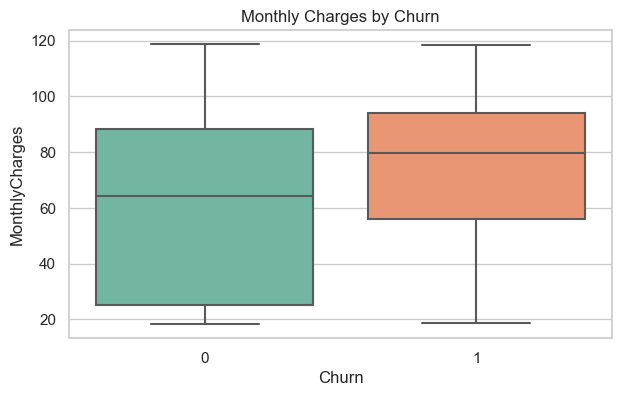

In [6]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set2')
plt.title('Monthly Charges by Churn')
plt.show()

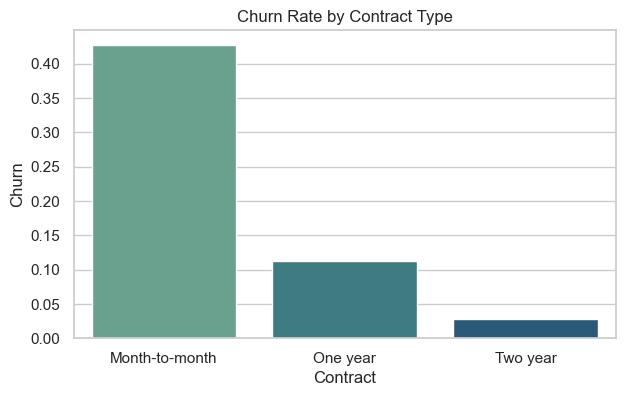

In [7]:
contract_rates = df.groupby('Contract', as_index=False)['Churn'].mean().sort_values('Churn', ascending=False)
plt.figure(figsize=(7, 4))
sns.barplot(data=contract_rates, x='Contract', y='Churn', palette='crest')
plt.title('Churn Rate by Contract Type')
plt.show()

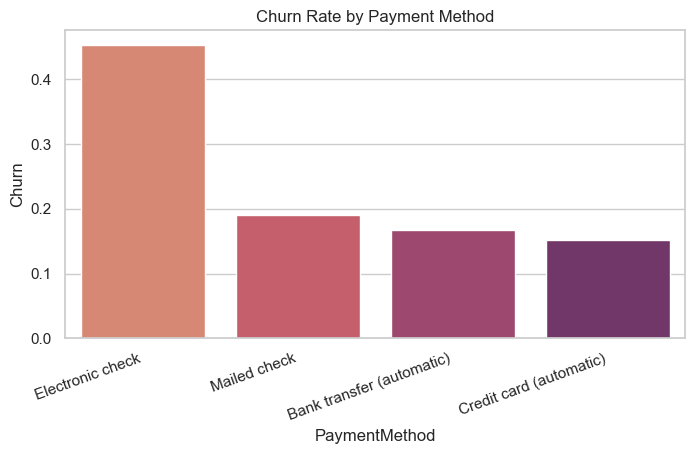

In [8]:
payment_rates = df.groupby('PaymentMethod', as_index=False)['Churn'].mean().sort_values('Churn', ascending=False)
plt.figure(figsize=(8, 4))
sns.barplot(data=payment_rates, x='PaymentMethod', y='Churn', palette='flare')
plt.xticks(rotation=20, ha='right')
plt.title('Churn Rate by Payment Method')
plt.show()

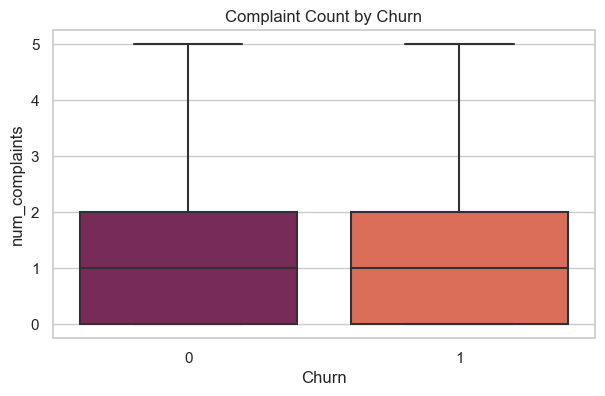

In [9]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='Churn', y='num_complaints', palette='rocket')
plt.title('Complaint Count by Churn')
plt.show()

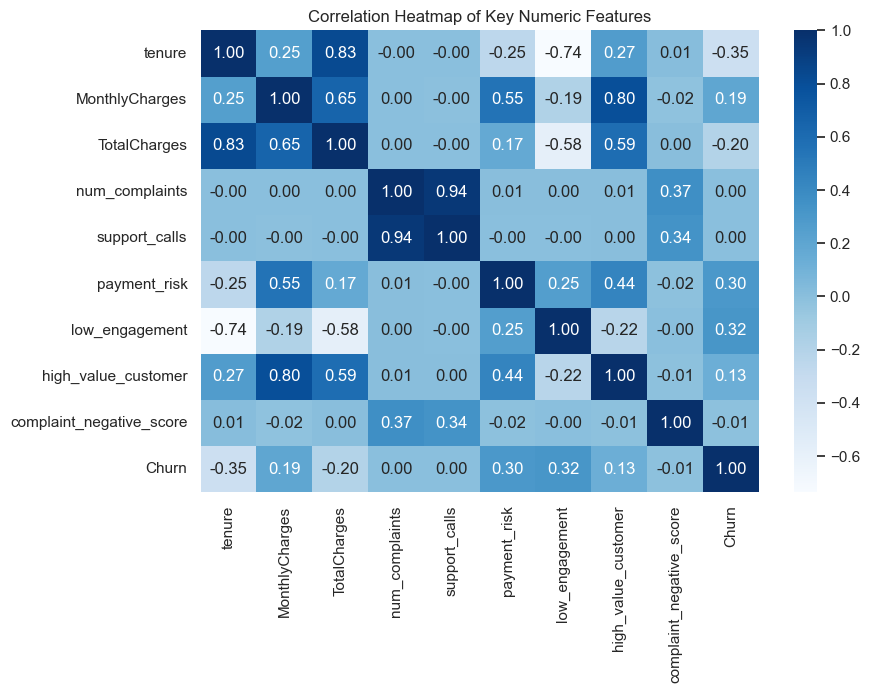

In [10]:
corr_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'num_complaints', 'support_calls', 'payment_risk', 'low_engagement', 'high_value_customer', 'complaint_negative_score', 'Churn']
plt.figure(figsize=(9, 6))
sns.heatmap(df[corr_cols].corr(numeric_only=True), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap of Key Numeric Features')
plt.show()

I saved the polished PNG versions of these plots into `outputs/eda/`:

```python
!python ../src/generate_eda.py
```